In [1]:
# Permite ajustar la anchura de la parte útil de la libreta (reduce los márgenes)
from IPython.core.display import display, HTML
display(HTML("<style>.container{ width:85% }</style>"))

import warnings
warnings.filterwarnings("ignore")

/tmp/ipykernel_1429084/363030204.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


# **Introducción a FinRL y Proyecto de Extensión Multiobjetivo**

---

## ¿Qué es FinRL?

**FinRL** es un marco de trabajo de **aprendizaje por refuerzo profundo (Deep Reinforcement Learning, DRL)** enfocado en aplicaciones financieras, especialmente en la **gestión automatizada de portafolios**.

Su objetivo es proporcionar herramientas listas para usar que permitan a investigadores y profesionales implementar agentes inteligentes que aprendan a **tomar decisiones de inversión** en entornos de mercado realistas.

### Principales características:

- Integra algoritmos de DRL como: `DQN`, `A2C`, `PPO`, `DDPG`, `SAC`, entre otros.
- Soporta fuentes de datos como **Yahoo Finance**, **Alpaca**, y otros proveedores.
- Incluye entornos de simulación que consideran:
  - Costos de transacción
  - Límites de compra/venta
  - Turbulencia del mercado
- Herramientas integradas para:
  - Preprocesamiento de datos financieros
  - Ingeniería de características técnicas
  - Evaluación de estrategias de inversión

---

## Descripción del Proyecto

Este proyecto extiende FinRL hacia un escenario **multiobjetivo**, donde el agente no solo busca **maximizar el retorno financiero**, sino que también debe:

-  **Minimizar el riesgo** (medido por la volatilidad del portafolio)
- **Promover la sostenibilidad** (mediante un indicador ESG: Environmental, Social, Governance)

### ¿Qué se implementó?

1. **Modificación del entorno** `StockTradingEnv` para incluir una **recompensa vectorial**:
   - $r_1$: retorno financiero
   - $r_2$: penalización por riesgo (volatilidad)
   - $r_3$: score de sostenibilidad (ESG)

2. **Scalarización de recompensas**:
   - Se combinan en una única señal mediante una función lineal ponderada:
     $$
     r = \lambda_1 r_1 + \lambda_2 r_2 + \lambda_3 r_3
     $$

3. **Entrenamiento de un agente PPO** utilizando esta nueva recompensa compuesta.

4. **Evaluación comparativa** frente a otras estrategias:
   - **PPO tradicional** (solo maximiza retorno)
   - **Optimización media-varianza (MVO)**
   - **Índice Dow Jones (DJI)** como benchmark del mercado

---

## Impacto y Relevancia

Este proyecto demuestra cómo adaptar bibliotecas existentes de DRL para incorporar **criterios de inversión más complejos y éticamente responsables**, alineándose con tendencias actuales en:

- Finanzas sostenibles
- Inversión responsable
- Inteligencia artificial con propósito social

Además, permite explorar **nuevos perfiles de inversor** al modificar los pesos $(\lambda_1, \lambda_2, \lambda_3)$, generando agentes más conservadores, sostenibles o balanceados según el enfoque deseado.

# Se importan las librerías

In [2]:
# Librerías estándar
import os
import sys
import datetime
import itertools

# Librerías de análisis y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Librerías para entornos de Gym y FinRL
import gym
from gym import spaces
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
from stable_baselines3.common.logger import configure

# Módulos de FinRL
from finrl import config_tickers
from finrl.config import INDICATORS, TRAINED_MODEL_DIR, RESULTS_DIR
from finrl.main import check_and_make_directories
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split

# Asegura que los directorios para modelos y resultados estén creados
check_and_make_directories([TRAINED_MODEL_DIR])

# Habilita la visualización en notebooks (opcional si estás fuera de Jupyter)
%matplotlib inline

2025-05-21 13:55:13.521281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-21 13:55:13.536734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-21 13:55:13.555899: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-21 13:55:13.561735: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-21 13:55:13.576119: I tensorflow/core/platform/cpu_feature_guar

# Preparación de Datos para Entrenar un Agente de Trading con FinRL

Se prepara un conjunto de datos financieros utilizando el framework FinRL, con el objetivo de entrenar un agente de aprendizaje por refuerzo en un entorno de trading automatizado.

---

### Rango de Fechas

- Entrenamiento: 2009–2023  
- Prueba (trading): 2023–2025

Esto permite evaluar al agente en datos no vistos durante el entrenamiento.

---

### Selección de Activos

Se eligen varias empresas del mercado bursátil (como Apple, Microsoft, Meta, etc.) y se descargan sus datos históricos mediante `YahooDownloader`.

---

### Ingeniería de Características

Se generan indicadores financieros relevantes, tales como:

- Indicadores técnicos (RSI, MACD, SMA)
- Volatilidad del mercado (VIX)
- Turbulencia

Estas variables enriquecen el estado que observa el agente.

---

### Relleno de Fechas Faltantes

Se construye una matriz completa con todas las combinaciones de fechas y activos, rellenando con ceros aquellos casos donde falten datos.

---

### División del Dataset

El conjunto total se divide en:

- `train`: datos utilizados para entrenar al agente
- `trade`: datos utilizados para probar su capacidad de generalización

---

### Cálculo del Espacio de Estados

El espacio de estados representa toda la información disponible para el agente y se define como:

$$
\text{state\_space} = 1 + 2 \times \text{stock_dimension} + (\text{len(indicators)} \times \text{stock_dimension})
$$

Este incluye:

- Efectivo disponible
- Cantidad de acciones en portafolio
- Precios actuales de cada acción
- Indicadores técnicos por acción

Esta representación proporciona al agente la información necesaria para tomar decisiones de compra, venta o retención en función del estado del mercado y del portafolio.


In [3]:
# Fechas de entrenamiento y de operación (trading)
# Fechas de entrenamiento y de operación (trading)
TRAIN_START_DATE = '2009-01-01'
TRAIN_END_DATE = '2023-01-01'       # Entrenamiento hasta inicios de 2023
TRADE_START_DATE = '2023-01-01'     # Prueba desde 2023 en adelante
TRADE_END_DATE = '2025-05-20'       # Última fecha con datos disponibles


# Lista de símbolos (tickers) a descargar desde Yahoo Finance
symbols = [
    'aapl',
    'msft',
    'meta',
    'ibm',
    'hd',
    'cat',
    'amzn',
    'intc',
    't',
    'vgs'
]

# Descarga de datos históricos con YahooDownloader desde FinRL
df_raw = YahooDownloader(
    start_date=TRAIN_START_DATE,
    end_date=TRADE_END_DATE,
    ticker_list=symbols
).fetch_data()

# Ingeniería de características: indicadores técnicos, VIX y turbulencia
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=True,
    use_turbulence=True,
    user_defined_feature=False
)

# Procesamiento de los datos crudos descargados
processed = fe.preprocess_data(df_raw)

# Genera todas las combinaciones posibles de fecha y ticker
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(), processed['date'].max()).astype(str))
combination = list(itertools.product(list_date, list_ticker))

# Completa el DataFrame con fechas faltantes para cada ticker
processed_full = pd.DataFrame(combination, columns=["date", "tic"]).merge(
    processed, on=["date", "tic"], how="left"
)

# Conserva solo las fechas originales disponibles
processed_full = processed_full[processed_full['date'].isin(processed['date'])]

# Ordena por fecha y ticker
processed_full = processed_full.sort_values(['date', 'tic'])

# Rellena los valores faltantes con ceros
processed_full = processed_full.fillna(0)

# Divide el dataset en conjunto de entrenamiento y de prueba (trading)
train = data_split(processed_full, TRAIN_START_DATE, TRAIN_END_DATE)
trade = data_split(processed_full, TRADE_START_DATE, TRADE_END_DATE)

# Muestra la cantidad de registros en cada conjunto
print(len(train))
print(len(trade))

# Número de empresas únicas (tickers)
stock_dimension = len(train.tic.unique())

# Tamaño del espacio de estados:
# 1 (balance) + 2 * stock_dimension (precio y cantidad de acciones)
# + indicadores técnicos para cada acción
state_space = 1 + 2 * stock_dimension + len(INDICATORS) * stock_dimension

# Imprime detalles sobre el espacio de estados
print(f"Number of Indicators: {len(INDICATORS)}")
print(f"Stock Dimension: {stock_dimension}")
print(f"state_space = 1 + 2*{stock_dimension} + ({len(INDICATORS)})*{stock_dimension}")
print(f"State Space: {state_space}")

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (37593, 8)
Successfully added technical indicators


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (4119, 8)
Successfully added vix
Successfully added turbulence index
28192
4760
Number of Indicators: 8
Stock Dimension: 8
state_space = 1 + 2*8 + (8)*8
State Space: 81


## Evaluación del Agente

Una vez entrenado, el agente se prueba en un entorno con **datos no vistos** para verificar si su política de inversión es efectiva y generalizable.

Durante la evaluación:

- El agente recibe estados del mercado y toma decisiones (comprar, vender, mantener).
- El entorno actualiza el valor del portafolio según esas decisiones.
- Se registran las acciones y el valor del portafolio a lo largo del tiempo.

---

## Objetivo

Evaluar si el agente:

- Genera retornos sostenibles.
- Controla el riesgo.
- Se comporta coherentemente con su entrenamiento.

También permite calcular métricas como:

- **Retorno total**
- **Sharpe ratio**
- **Máximo drawdown**

Y comparar su desempeño contra estrategias clásicas o benchmarks como el índice **Dow Jones (DJI)**.


In [4]:
# === Configuración de costos de transacción y acciones iniciales ===
buy_cost_list = sell_cost_list = [0.001] * stock_dimension  # Costos de compra/venta del 0.1% por acción
num_stock_shares = [0] * stock_dimension  # El portafolio comienza sin acciones

# === Diccionario de argumentos para inicializar el entorno de FinRL ===
env_kwargs = {
    "hmax": 100,  # Máximo de acciones que se pueden comprar o vender por día
    "initial_amount": 1000000,  # Capital inicial en dólares
    "num_stock_shares": num_stock_shares,  # Acciones poseídas al inicio (todas en 0)
    "buy_cost_pct": buy_cost_list,  # Costos por compra
    "sell_cost_pct": sell_cost_list,  # Costos por venta
    "state_space": state_space,  # Dimensión del estado (definido previamente)
    "stock_dim": stock_dimension,  # Número de activos (acciones distintas)
    "tech_indicator_list": INDICATORS,  # Lista de indicadores técnicos a usar
    "action_space": stock_dimension,  # El espacio de acción tiene una dimensión por acción
    "reward_scaling": 1e-4  # Factor de escala para estabilizar la recompensa
}

# === Crear entorno de prueba (trading) con turbulencia ===
# Se usa el entorno clásico de FinRL (StockTradingEnv), no el multiobjetivo
e_trade_gym = StockTradingEnv(
    df=trade,  # Dataset de prueba
    turbulence_threshold=70,  # Umbral de turbulencia del mercado
    risk_indicator_col='vix',  # Indicador de riesgo a considerar (VIX)
    **env_kwargs  # Se pasan los parámetros definidos anteriormente
)

if_using_ppo = True

ruta = "./results/ppo/agent_ppo"
trained_ppo = PPO.load(ruta) if if_using_ppo else None

# === Evaluación del modelo PPO entrenado ===

# La función DRL_prediction evalúa el desempeño del agente en el entorno proporcionado.
# Devuelve:
# - df_account_value_ppo: evolución del valor del portafolio durante el periodo de prueba
# - df_actions_ppo: las acciones tomadas (compra/venta) por el agente PPO
df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_ppo,            # Modelo PPO previamente entrenado
    environment=e_trade_gym       # Entorno de prueba para simulación
) if if_using_ppo else (None, None)  # Solo se ejecuta si `if_using_ppo` es True

hit end!


## Preparación de Datos para Optimización de Portafolios (MVO)

Se procesan datos históricos de precios para generar las estructuras necesarias para aplicar modelos clásicos como la **Media-Varianza de Markowitz (MVO)**.

---

### Funciones clave

- **`process_df_for_mvo(df)`**: genera una matriz de precios de cierre con fechas como filas y tickers como columnas.
- **`StockReturnsComputing(...)`**: a partir de esa matriz, calcula los **rendimientos diarios porcentuales** por activo.

---

### ¿Qué se obtiene?

- Una **matriz de precios** organizada por activo y fecha.
- Una **matriz de rendimientos diarios**, base para análisis estadístico.

Estas salidas permiten calcular medias, varianzas, matrices de covarianza y aplicar técnicas de optimización de portafolio enfocadas en el balance entre **riesgo y retorno**.

In [5]:
# Función que convierte un DataFrame largo (con columnas 'date', 'tic', 'close') 
# en una matriz de precios con fechas como índice y tickers como columnas.
def process_df_for_mvo(df):
  # Ordena el DataFrame por fecha y ticker, y se queda solo con las columnas necesarias
  df = df.sort_values(['date','tic'], ignore_index=True)[['date','tic','close']]
  
  # Toma el primer bloque de datos (una fila por ticker) para extraer la lista de símbolos (tic)
  fst = df.iloc[0:stock_dimension, :]
  tic = fst['tic'].tolist()

  # Inicializa un DataFrame vacío con columnas = tickers, que almacenará los precios por día
  mvo = pd.DataFrame()
  for k in range(len(tic)):
    mvo[tic[k]] = 0  # Llena con ceros inicialmente

  # Recorre el DataFrame completo por bloques (cada bloque corresponde a un día completo)
  for i in range(df.shape[0] // stock_dimension):
    n = df.iloc[i * stock_dimension:(i+1) * stock_dimension, :]  # bloque de datos para una fecha
    date = n['date'].iloc[0]  # extrae la fecha correspondiente a ese bloque
    mvo.loc[date] = n['close'].tolist()  # asigna precios de cierre a esa fecha

  # Devuelve un DataFrame con fechas como índice y tickers como columnas
  return mvo


# Función que calcula los rendimientos diarios (porcentuales) de cada acción a partir de la matriz de precios
def StockReturnsComputing(StockPrice, Rows, Columns):
  import numpy as np
  
  # Inicializa una matriz de ceros para los rendimientos
  # Tiene una fila menos porque los rendimientos se calculan entre pares de días
  StockReturn = np.zeros([Rows - 1, Columns])
  
  # Calcula los rendimientos porcentuales por activo
  for j in range(Columns):        # j recorre las columnas (acciones)
    for i in range(Rows - 1):     # i recorre las filas (días)
      StockReturn[i, j] = ((StockPrice[i+1, j] - StockPrice[i, j]) / StockPrice[i, j]) * 100

  # Devuelve la matriz de rendimientos
  return StockReturn


StockData = process_df_for_mvo(train)
TradeData = process_df_for_mvo(trade)

TradeData.to_numpy()


# Convierte el DataFrame de precios en un arreglo NumPy para facilitar los cálculos
arStockPrices = np.asarray(StockData)

# Extrae el número de filas (días) y columnas (activos) del arreglo de precios
[Rows, Cols] = arStockPrices.shape

# Calcula los rendimientos porcentuales diarios usando la función definida previamente
# arReturns tendrá forma (Rows - 1, Cols), es decir, un rendimiento por día y por activo
arReturns = StockReturnsComputing(arStockPrices, Rows, Cols)

# Calcula los rendimientos medios diarios para cada activo (promedio de cada columna)
meanReturns = np.mean(arReturns, axis=0)

# Calcula la matriz de varianzas y covarianzas de los rendimientos
# Esto representa el riesgo y las correlaciones entre activos
covReturns = np.cov(arReturns, rowvar=False)

# Configura la salida de NumPy para mostrar solo 3 decimales y sin notación científica
np.set_printoptions(precision=3, suppress=True)

# Imprime los resultados: los rendimientos medios diarios y la matriz de covarianza
print('Mean returns of assets in k-portfolio 1\n', meanReturns)
print('Variance-Covariance matrix of returns\n', covReturns)

Mean returns of assets in k-portfolio 1
 [0.126 0.121 0.077 0.095 0.038 0.046 0.093 0.033]
Variance-Covariance matrix of returns
 [[3.358 1.909 1.555 1.362 1.142 1.785 1.793 0.817]
 [1.909 4.796 1.51  1.399 1.055 1.65  2.061 0.711]
 [1.555 1.51  3.936 1.448 1.454 1.827 1.537 1.135]
 [1.362 1.399 1.448 2.401 1.078 1.469 1.408 0.866]
 [1.142 1.055 1.454 1.078 2.086 1.376 1.189 0.943]
 [1.785 1.65  1.827 1.469 1.376 3.598 1.94  1.008]
 [1.793 2.061 1.537 1.408 1.189 1.94  2.876 0.822]
 [0.817 0.711 1.135 0.866 0.943 1.008 0.822 1.664]]


# Optimización de Portafolio con la Frontera Eficiente (Modelo de Markowitz)

Se aplica la teoría de media-varianza de Markowitz usando la librería `PyPortfolioOpt` para construir un portafolio óptimo que **maximice el rendimiento ajustado al riesgo**.

---

### ¿Qué es la frontera eficiente?

Es el conjunto de portafolios que ofrecen:

- El **mayor retorno esperado** para un nivel de riesgo dado, o
- El **menor riesgo posible** para un retorno esperado.

Uno de los puntos clave es el portafolio con **máxima relación de Sharpe**.

---

### ¿Qué hace la optimización?

1. **Entrada**:
   - Retornos esperados por activo.
   - Matriz de covarianza de rendimientos.
   - Límites sobre los pesos de cada activo.

2. **Criterio**:
   - **Maximizar la relación de Sharpe**:
     $$
     \text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}
     $$

3. **Salida**:
   - Pesos óptimos para asignar capital entre los activos.

---

### ¿Qué representa el resultado?

El portafolio resultante es:

- Diversificado
- Eficiente
- Ajustado a las restricciones del inversionista

Este enfoque proporciona una base cuantitativa sólida para tomar decisiones de inversión estructuradas.


In [6]:
# Importa la clase EfficientFrontier de la librería PyPortfolioOpt,
# que permite construir portafolios óptimos bajo diferentes criterios (Sharpe, riesgo mínimo, etc.)
from pypfopt.efficient_frontier import EfficientFrontier

# Crea un optimizador de portafolio usando los retornos medios y la matriz de covarianza
# Se imponen límites a los pesos: cada activo puede tener entre 0% y 50% del portafolio
ef_mean = EfficientFrontier(meanReturns, covReturns, weight_bounds=(0, 0.5))

# Calcula los pesos que maximizan la relación de Sharpe del portafolio
# Esto busca el mejor trade-off entre retorno esperado y riesgo (volatilidad)
raw_weights_mean = ef_mean.max_sharpe()

# Limpia los pesos: elimina valores cercanos a cero y los redondea para interpretación más clara
cleaned_weights_mean = ef_mean.clean_weights()

# Convierte los pesos proporcionales a cantidades monetarias, asumiendo un capital total de $1,000,000
# Se genera un arreglo NumPy con 8 valores, uno por cada acción (orden según los tickers originales)
mvo_weights = np.array([1000000 * cleaned_weights_mean[i] for i in range(8)])

# Visualiza el resultado: cuánto invertir en cada activo para maximizar el Sharpe ratio
mvo_weights

array([434140., 179540.,      0., 371050.,      0.,      0.,  15270.,
            0.])

### Teoría de la Relación de Sharpe y Optimización de Portafolio

La **relación de Sharpe** mide el rendimiento ajustado al riesgo de un portafolio. Se define como:

$$
\text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}
$$

Donde:
- $\mathbb{E}[R_p]$ es el retorno esperado,
- $R_f$ la tasa libre de riesgo,
- $\sigma_p$ la volatilidad del portafolio.

Un mayor Sharpe indica mejor eficiencia en la relación retorno/riesgo.

---

### Optimización con PyPortfolioOpt

Se usa la teoría de Markowitz para construir un portafolio óptimo que **maximice la relación de Sharpe**, dados los retornos esperados y la matriz de covarianza.

**Resultado**: una distribución óptima de pesos que indica cuánto capital asignar a cada activo.

---

### Interpretación de los Pesos Óptimos

Los pesos indican cuánto invertir en cada activo. Algunos activos pueden recibir peso cero si no mejoran la eficiencia del portafolio.

---

### Conversión a Unidades de Activos

Para implementar el portafolio, se convierten los pesos monetarios en **número de acciones** usando los precios actuales:

$$
\text{acciones} = \frac{\text{dinero asignado}}{\text{precio actual}}
$$

Esto permite simular o ejecutar el portafolio de forma práctica.

---

In [7]:
# Obtiene la última fila del DataFrame de precios (StockData), que contiene los precios de cierre más recientes
# Convierte esa fila en un arreglo NumPy de una dimensión
# Luego, calcula el recíproco (1/precio) de cada precio, para usarlo como factor de conversión
# Esto permite más adelante convertir montos en dólares a número de acciones
LastPrice = np.array([1/p for p in StockData.tail(1).to_numpy()[0]])

# Multiplica los montos asignados a cada activo (mvo_weights) por 1/precio
# Resultado: cuántas acciones se pueden comprar de cada activo con el dinero asignado
Initial_Portfolio = np.multiply(mvo_weights, LastPrice)

# Muestra el portafolio inicial expresado como número de acciones por activo
Initial_Portfolio

array([3384.62 , 2137.381,    0.   , 1244.843,    0.   ,    0.   ,
         64.967,    0.   ])

### Evaluación del Portafolio Optimizado (Media-Varianza)

Una vez calculadas las unidades de cada activo a comprar según el modelo de media-varianza, se evalúa la evolución del portafolio bajo una estrategia **buy-and-hold** (mantener sin rebalanceo).

---

### ¿Cómo se hace?

- Se usa un vector (`Initial_Portfolio`) con la cantidad de acciones por activo.
- Se multiplica por una matriz de precios históricos (`TradeData`) para obtener el valor total del portafolio día a día.

$$
\text{Valor_diario}_t = \sum_{i=1}^{N} \text{Precio}_{i,t} \cdot \text{Acciones}_i
$$

---

### ¿Qué se obtiene?

Un `DataFrame` con la evolución diaria del valor del portafolio optimizado.

---

### ¿Para qué sirve?

- Visualizar el desempeño del portafolio en el tiempo.
- Compararlo con otras estrategias (como PPO o DJI).
- Calcular métricas como retorno total, Sharpe ratio y drawdown.

In [8]:
Portfolio_Assets = TradeData @ Initial_Portfolio
MVO_result = pd.DataFrame(Portfolio_Assets, columns=["Mean Var"])

### ¿Qué es el Dow Jones Industrial Average (DJI)?

El **DJI** es un índice bursátil histórico que representa el desempeño de **30 grandes empresas estadounidenses**. Fue creado en 1896 y es uno de los principales indicadores del estado del mercado en Estados Unidos.

---

### Características clave

- Es un índice **ponderado por precio**, no por capitalización.
- Incluye empresas líderes de distintos sectores como tecnología, salud y finanzas.
- Se considera un **referente del mercado tradicional** y es ampliamente seguido.

---

### ¿Por qué se usa como benchmark?

- Tiene una trayectoria histórica confiable.
- Resume el comportamiento de empresas sólidas del mercado estadounidense.
- Sirve para **comparar el rendimiento de estrategias de inversión** como RL o MVO.

---

### Normalización a 1,000,000

Para comparar visualmente el desempeño del DJI con un portafolio simulado, se escala su valor inicial a **1,000,000**. Esto permite:

- Igualar las condiciones de comparación.
- Evaluar si una estrategia supera al mercado (alpha positiva).
- Medir desempeño relativo de forma clara.

---

In [9]:
df_dji = YahooDownloader(start_date = TRADE_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ['^dji']).fetch_data()


# Selecciona solo las columnas 'date' y 'close' del índice Dow Jones
df_dji = df_dji[['date','close']]

# Obtiene el precio de cierre del primer día (se usará como referencia para normalizar)
fst_day = df_dji['close'][0]

# Normaliza los precios dividiendo entre el precio del primer día y escalando a 1,000,000
# Esto transforma la serie para que comience en 1,000,000, facilitando la comparación con otros portafolios
# Luego une las fechas con esta serie transformada y establece 'date' como índice
dji = pd.merge(
    df_dji['date'],                                   # columna de fechas
    df_dji['close'].div(fst_day).mul(1000000),        # serie normalizada
    how='outer',
    left_index=True,
    right_index=True
).set_index('date')                                   # establece 'date' como índice temporal



# Si estás usando PPO, toma el DataFrame de resultados (valor del portafolio por día)
# y establece la primera columna (que contiene las fechas) como índice temporal
df_result_ppo = df_account_value_ppo.set_index(df_account_value_ppo.columns[0]) if if_using_ppo else None

# Inicializa un DataFrame vacío para ir construyendo una tabla comparativa de resultados
result = pd.DataFrame()

# Si se está usando PPO, fusiona (merge) el DataFrame vacío con los resultados del PPO
# La fusión se hace con 'outer' join, para conservar todas las fechas posibles
# Se usa el índice (fechas) como clave para alinear los datos
if if_using_ppo:
    result = pd.merge(result, df_result_ppo, how='outer', left_index=True, right_index=True)

[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (596, 8)


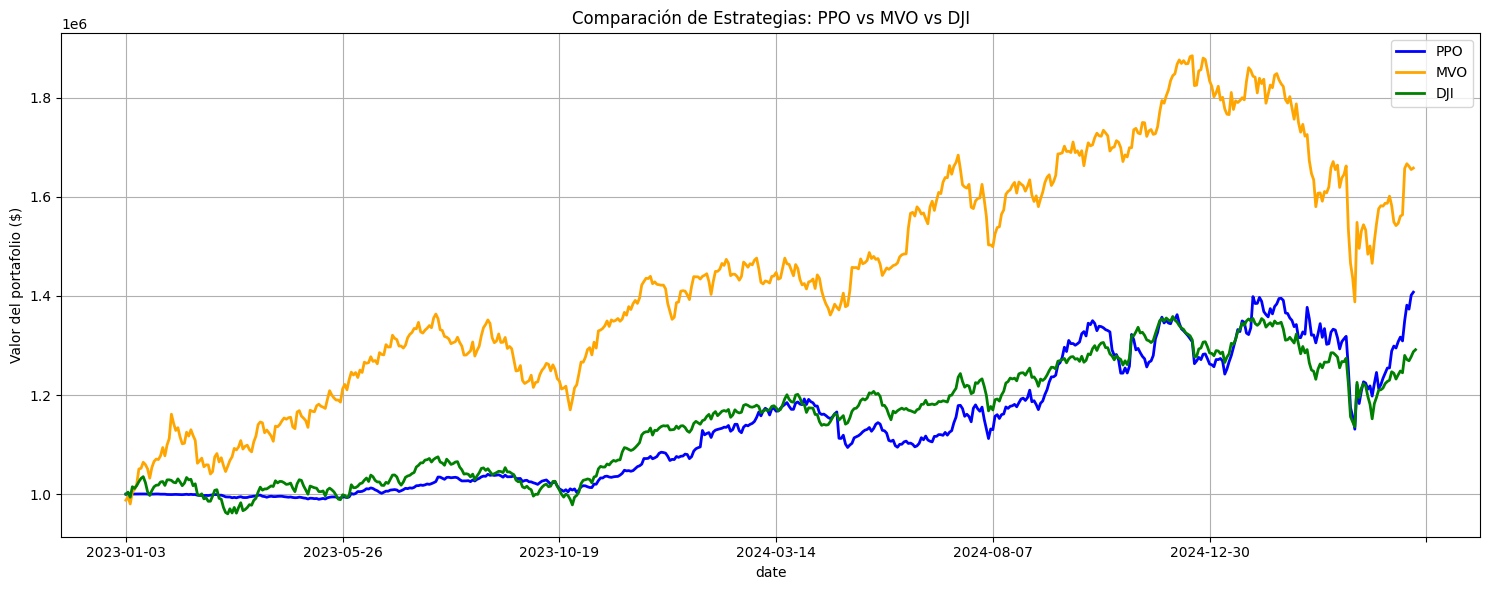

In [10]:
# Crea una lista vacía para los nombres de columnas
col_name = []

# Si estás usando PPO, agrega 'PPO' como nombre de columna para el DataFrame resultante
col_name.append('PPO') if if_using_ppo else None

# Asigna los nombres de columna al DataFrame 'result'
result.columns = col_name

# Agrega MVO y DJI
result = pd.merge(result, MVO_result, how='outer', left_index=True, right_index=True)
result = pd.merge(result, dji, how='outer', left_index=True, right_index=True).fillna(method='bfill')

# Renombra las columnas si no tienen los nombres correctos
# Esto es útil si MVO_result o dji tienen nombres automáticos como "account_value"
result.columns = ['PPO', 'MVO', 'DJI']

# Configura el tamaño de la figura
plt.rcParams["figure.figsize"] = (15, 6)

# Dibuja la gráfica con colores personalizados
result.plot(
    title="Comparación de Estrategias: PPO vs MVO vs DJI",
    color={
        'PPO': 'blue',
        'MVO': 'orange',
        'DJI': 'green'
    },
    linewidth=2
)

plt.ylabel("Valor del portafolio ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("Estrategias_normales.png")
plt.show()

# **Extensión del Entorno de Trading de FinRL a un Escenario Multiobjetivo**

---

## ¿Qué se hizo?

Se modificó el entorno de entrenamiento de FinRL para incorporar un enfoque **multiobjetivo**, permitiendo que el agente aprenda a tomar decisiones de inversión que no solo maximicen la ganancia financiera, sino que también consideren el **riesgo** y la **sostenibilidad (ESG)**.

---

## ¿Por qué es relevante?

En el mundo real, los inversionistas no se guían únicamente por el retorno económico. Las decisiones modernas también incluyen:

- **Rentabilidad**: buscar maximizar el valor del portafolio.
- **Riesgo**: reducir la exposición a pérdidas o alta volatilidad.
- **Sostenibilidad (ESG)**: priorizar empresas responsables con el ambiente, la sociedad y la gobernanza.

Estos objetivos suelen entrar en conflicto. Por ejemplo, una empresa puede ser muy rentable pero riesgosa o tener malas prácticas ambientales. Por ello, usamos un enfoque de aprendizaje por refuerzo que pueda considerar todos estos factores simultáneamente.

---

## ¿Qué se modificó?

1. **Se creo una nueva versión del entorno** llamada `StockTradingMultiEnv`, extendida desde `StockTradingEnv`, que soporta:
   - Recompensas vectoriales:  
     $$
     \mathbf{r}_t = [r_{\text{retorno}}(t),\ r_{\text{riesgo}}(t),\ r_{\text{esg}}(t)]
     $$
   - Scalarización lineal con pesos:  
     $$
     r_t = \lambda_1 r_{\text{retorno}} + \lambda_2 r_{\text{riesgo}} + \lambda_3 r_{\text{esg}}
     $$

2. **Se definió cada componente de la recompensa**:
   - **Retorno ($r_1$)**: cambio porcentual en el valor del portafolio.
   - **Riesgo ($r_2$)**: penalización basada en la volatilidad reciente del portafolio.
   - **ESG ($r_3$)**: promedio ponderado de los puntajes ESG de los activos en posesión.

3. **Se asignaron puntajes ESG** simulados mediante un diccionario `ESG_dict`, donde cada activo recibe un valor entre 0 y 1.

4. **Se evitaron errores con activos nuevos** usando `defaultdict`, asignando un valor neutral por defecto (por ejemplo, 0.5) a los activos sin puntaje ESG explícito.

5. **Se entrenó un agente PPO** sobre este entorno. La política aprendida depende de los pesos $\lambda_i$ definidos, lo que permite representar diferentes perfiles de inversionistas.

---

## ¿Qué se logró?

Ahora tenemos un entorno de aprendizaje por refuerzo capaz de modelar decisiones de inversión **más realistas y conscientes**, que toman en cuenta:

- Ganancia esperada
- Riesgo asumido
- Sostenibilidad de las inversiones

Además, al modificar los pesos $\lambda$, podemos ajustar las prioridades del agente y analizar cómo cambia su comportamiento según diferentes estrategias o perfiles de riesgo.

---
<!-- 
#### 🚀 ¿Qué sigue?

Esta extensión permite explorar nuevas líneas de investigación y experimentación, como:

- Comparar agentes con y sin conciencia ESG.
- Visualizar el trade-off entre retorno y riesgo.
- Evaluar políticas bajo distintos perfiles de inversión (conservador, balanceado, sostenible). -->


In [11]:
class StockTradingMultiEnv(gym.Env):
    """Entorno de trading multiobjetivo con scalarización."""
    metadata = {'render.modes': ['human']}

    def __init__(self,
                 df,
                 stock_dim,
                 hmax,
                 initial_amount, 
                 buy_cost_pct,
                 sell_cost_pct, 
                 reward_scaling,
                 state_space,
                 action_space,
                 tech_indicator_list, 
                 lambda1=1.0,
                 lambda2=0.0,
                 lambda3=0.0,
                 esg_dict=None):
        
        super(StockTradingMultiEnv, self).__init__()
        
        # --- Parámetros del entorno base ---
        self.df = df.reset_index(drop=True)  # DataFrame de entrada, reinicia índice
        self.stock_dim = stock_dim  # Número de acciones diferentes
        self.hmax = hmax  # Máximo número de acciones que se pueden comprar/vender
        self.initial_amount = initial_amount  # Cantidad inicial de dinero
        self.buy_cost_pct = buy_cost_pct  # Costos porcentuales al comprar (puede ser array)
        self.sell_cost_pct = sell_cost_pct  # Costos porcentuales al vender (puede ser array)
        self.reward_scaling = reward_scaling  # Factor para escalar las recompensas
        self.state_space = state_space  # Dimensión del espacio de estado
        self.action_space = action_space  # Dimensión del espacio de acción
        self.tech_indicator_list = tech_indicator_list  # Lista de indicadores técnicos a usar

        # --- Parámetros adicionales multiobjetivo ---
        self.lambda1 = lambda1  # Peso del retorno financiero
        self.lambda2 = lambda2  # Peso del riesgo
        self.lambda3 = lambda3  # Peso del ESG
        self.esg_dict = esg_dict if esg_dict else {tic: 1.0 for tic in df.tic.unique()}  # Diccionario de scores ESG, default=1

        # --- Espacios de acción y observación ---
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.stock_dim,))  # Acciones continuas entre -1 y 1
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space,))  # Estado puede tener cualquier valor real
        
        # --- Estado inicial ---
        self.reset()

    def reset(self):
        self.day = 0  # Día actual dentro del DataFrame
        self.data = self.df.loc[self.df.date == self.df.date.unique()[self.day]]  # Subconjunto de datos para el día actual
        self.terminal = False  # Marca si el episodio terminó
        self.turbulence = 0  # Placeholder para posible uso de turbulencia
        self.tic_list = self.data.tic.values.tolist()  # Lista de tickers en orden
        self.num_stock_shares = [0] * self.stock_dim  # Inventario de acciones que se poseen
        self.stock_prices = self.data.close.values.tolist()  # Precios actuales de las acciones
        self.cash = self.initial_amount  # Dinero disponible
        self.portfolio_value = self.initial_amount  # Valor total del portafolio
        self.rewards = []  # Historial de recompensas
        self.asset_memory = [self.initial_amount]  # Historial del valor del portafolio
        self.account_memory = [[0, self.initial_amount]]  # Día y valor del portafolio
        self.actions_memory = []  # Historial de acciones tomadas

        state = self._get_state()
        return np.expand_dims(state, axis=0)  # SB3 espera shape (1, state_dim)

    def _get_state(self):
        self.data = self.df.loc[self.df.date == self.df.date.unique()[self.day]]  # Datos del día actual
        prices = self.data.close.values.tolist()  # Precios de cierre
        indicators = []
        for indicator in self.tech_indicator_list:
            indicators.extend(self.data[indicator].values.tolist())  # Concatenación de indicadores técnicos
        state = [self.cash] + self.num_stock_shares + prices + indicators  # Estado actual
        return np.array(state)

    def _calculate_rewards(self, prev_value):
        # r1: Retorno financiero basado en el cambio en el valor del portafolio
        current_value = self._get_portfolio_value()
        r1 = (current_value - prev_value) * self.reward_scaling

        # r2: Penalización por riesgo usando desviación estándar de los últimos 5 valores
        if len(self.asset_memory) > 5:
            r2 = -np.std(self.asset_memory[-5:]) / current_value
        else:
            r2 = 0

        # r3: ESG promedio ponderado por valor invertido en cada acción
        weights = np.array(self.num_stock_shares) * np.array(self.stock_prices)
        if weights.sum() > 0:
            norm_weights = weights / weights.sum()
        else:
            norm_weights = np.zeros_like(weights)
        esg_scores = np.array([self.esg_dict[tic] for tic in self.tic_list])
        r3 = np.dot(norm_weights, esg_scores)

        return r1, r2, r3

    def _get_portfolio_value(self):
        return self.cash + np.dot(self.stock_prices, self.num_stock_shares)  # cash + valor de las acciones

    def step(self, actions):
        self.terminal = self.day >= len(self.df.date.unique()) - 1  # Chequeo de fin de episodio
        if self.terminal:
            return self._get_state(), 0, self.terminal, {}  # Fin de episodio

        prev_value = self._get_portfolio_value()
        actions = (actions * self.hmax).astype(int)  # Escala las acciones a valores enteros
        self.stock_prices = self.data.close.values.tolist()  # Actualiza precios

        # Procesamiento de cada acción individual
        for i in range(self.stock_dim):
            if actions[i] > 0:
                buy_amount = min(self.cash // self.stock_prices[i], actions[i])  # Compra posible
                #if buy_amount > 0:
                    #print(...)  # Comentado para evitar spam
                cost = self.stock_prices[i] * buy_amount * (1 + self.buy_cost_pct[i])
                self.cash -= cost
                self.num_stock_shares[i] += buy_amount

            elif actions[i] < 0:
                sell_amount = min(self.num_stock_shares[i], -actions[i])  # Venta posible
                #if sell_amount > 0:
                    #print(...)
                gain = self.stock_prices[i] * sell_amount * (1 - self.sell_cost_pct[i])
                self.cash += gain
                self.num_stock_shares[i] -= sell_amount

        # Avanza al siguiente día
        self.day += 1
        self.data = self.df.loc[self.df.date == self.df.date.unique()[self.day]]
        self.stock_prices = self.data.close.values.tolist()

        new_value = self._get_portfolio_value()
        self.asset_memory.append(new_value)  # Guarda el nuevo valor

        # Cálculo de recompensas
        r1, r2, r3 = self._calculate_rewards(prev_value)
        reward = self.lambda1 * r1 + self.lambda2 * r2 + self.lambda3 * r3  # Scalarización

        # Actualiza historial
        self.account_memory.append([self.day, new_value])
        self.portfolio_value = new_value
        self.actions_memory.append(actions)

        return self._get_state(), reward, self.terminal, {"r1": r1, "r2": r2, "r3": r3}

    
    def get_sb_env():
        # Devuelve entorno envuelto como DummyVecEnvWithMemory (para usar con SB3)
        env = DummyVecEnvWithMemory([lambda: env_instance], env_instance)
        obs = env.reset()
        return env, obs  # SB3 espera (env, obs)

    
    def save_asset_memory(self):
        return pd.DataFrame(self.account_memory, columns=["date", "account_value"])  # Historial de valores del portafolio

    def save_action_memory(self):
        return pd.DataFrame(self.actions_memory)  # Historial de acciones tomadas

    

from stable_baselines3.common.vec_env import DummyVecEnv


# Clase personalizada que permite exponer métodos de memoria desde DummyVecEnv
class DummyVecEnvWithMemory(DummyVecEnv):
    def __init__(self, env_fns, original_env):
        super().__init__(env_fns)
        self.original_env = original_env  # Guarda el entorno original para delegar métodos

    def save_asset_memory(self):
        return self.original_env.save_asset_memory()  # Delegación

    def save_action_memory(self):
        return self.original_env.save_action_memory()

    def patch_get_sb_env(env_instance):
        # Función que parcha el método get_sb_env para que se pueda llamar desde un entorno cualquiera
        def get_sb_env():
            env = DummyVecEnvWithMemory([lambda: env_instance], env_instance)
            obs = env.reset()
            return env, obs
        env_instance.get_sb_env = get_sb_env  # Inyecta el método en el entorno


##  Indicador ESG utilizado

<!-- Para incorporar sostenibilidad en el proceso de decisión del agente, se adopta el enfoque planteado en el artículo:

> *“A Hierarchical Approach to a Tri-Objective Portfolio Optimization Problem Considering an ESG Index” (Mathematics, 2024)* -->

Este trabajo utiliza el **ESG Risk Score de Sustainalytics**, una métrica ampliamente aceptada que cuantifica el riesgo relacionado con factores ambientales, sociales y de gobernanza. En particular:

- El score ESG mide el nivel de exposición de una empresa a riesgos ESG materiales.
- Se expresa en una escala donde **valores bajos indican menor riesgo ESG** (mejor desempeño).
- Puede adaptarse como una utilidad directa o invertida para su uso como recompensa.

Dado que en FinRL no se tiene acceso directo a ESG reales en todos los activos, en este proyecto:

- Se utiliza una **versión simulada** del score ESG, consistente con el enfoque del artículo.
- A cada activo se le asigna un valor continuo entre 0 y 1 que representa su score ESG relativo.
- Este valor se utiliza en el entorno como **componente de recompensa** junto con retorno y riesgo, formando una recompensa vectorial escalarizada:

$$
r_t = \lambda_1 \cdot r_{\text{retorno}} + \lambda_2 \cdot r_{\text{riesgo}} + \lambda_3 \cdot r_{\text{ESG}}
$$

En fases posteriores, puede integrarse un score real a partir de fuentes públicas como Yahoo Finance, MSCI o Sustainalytics si se dispone de acceso.

# Comparación de Estrategias

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}


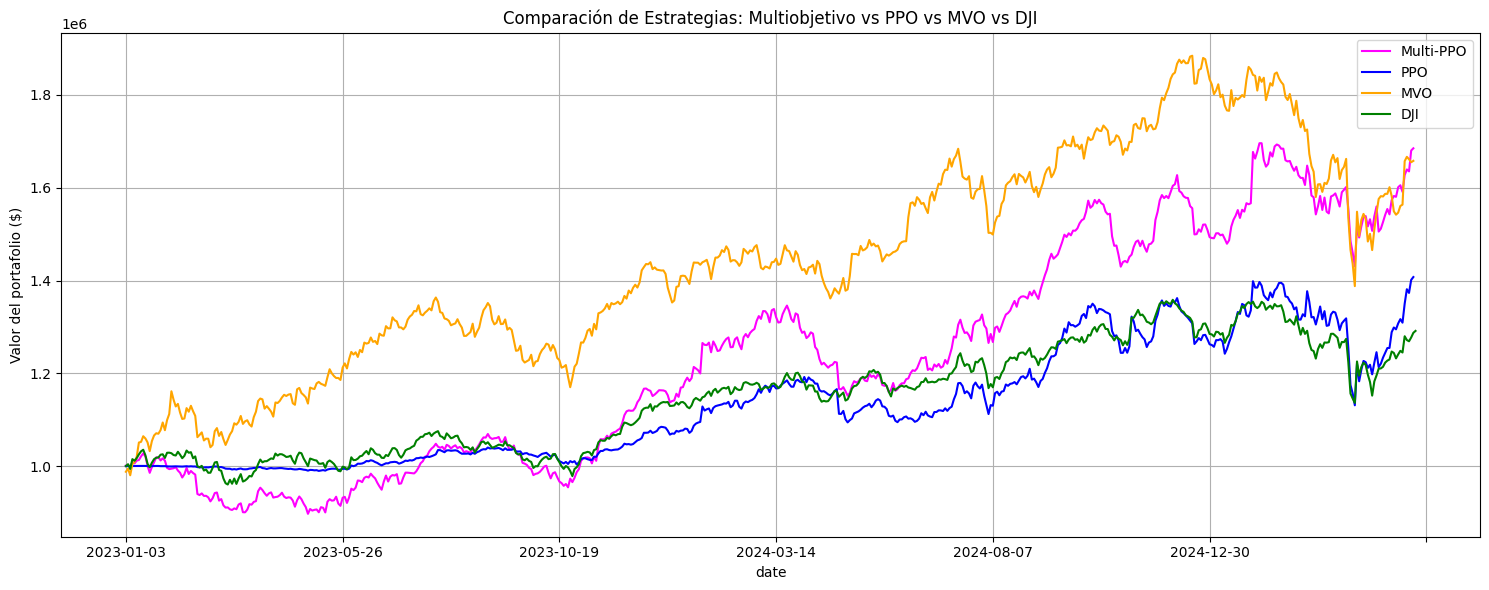

In [17]:
# === Importación de librerías ===
import pickle
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# === 1. Cargar conjuntos de entrenamiento y prueba ===
# Se hizo previamente

# === 2. Definir dimensiones del espacio de estados ===
# Se hizo previamente

# stock_dimension = len(train.tic.unique())  # Número de empresas únicas
# state_space = 1 + 2 * stock_dimension + len(INDICATORS) * stock_dimension  # Fórmula estándar de FinRL


# === 3. Configurar pesos para scalarización y diccionario ESG ===
# Estos valores fueron introducidos a "manita"
lambda1 = 1.0   # Retorno financiero
lambda2 = 0.5   # Penalización por riesgo
lambda3 = 2.0   # Sostenibilidad ESG


# Diccionario de puntajes ESG (valores por empresa entre 0 y 1)
ESG_dict = defaultdict(lambda: 0.5, {
    'aapl': 0.9,
    'msft': 0.8,
    'meta': 0.6,
    'ibm': 0.85,
    'hd': 0.7,
    'cat': 0.6,
    'amzn': 0.75,
    'intc': 0.65,
    't': 0.5,
    'vgs': 0.4  # ETF de bienes raíces, puntaje simulado
})


# === 4. Parámetros del entorno multiobjetivo ===
env_kwargs_multi = {
    "hmax": 1000,
    "initial_amount": 1_000_000,
    "buy_cost_pct": [0.001] * stock_dimension,
    "sell_cost_pct": [0.001] * stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "lambda1": lambda1,
    "lambda2": lambda2,
    "lambda3": lambda3,
    "esg_dict": ESG_dict
}

# === 5. Crear entorno y entrenar agente PPO ===
e_train_multi = StockTradingMultiEnv(df=train, **env_kwargs_multi)
agent_multi = DRLAgent(env=e_train_multi)
model_ppo_multi = agent_multi.get_model("ppo", verbose=0)

trained_ppo_multi = agent_multi.train_model(
    model=model_ppo_multi,
    tb_log_name='ppo_multi',
    total_timesteps=50_000
)

# === 6. Evaluar agente entrenado sobre conjunto de prueba ===
env = DummyVecEnv([lambda: StockTradingMultiEnv(df=trade, **env_kwargs_multi)])
obs = env.reset()

account_values = []
actions_taken = []

# Paso por cada día del periodo de prueba
for i in range(len(trade.date.unique()) - 1):
    action, _ = trained_ppo_multi.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

    raw_env = env.envs[0]
    account_values.append(raw_env.portfolio_value)
    actions_taken.append(action[0])

    if done:
        break  # Termina si el entorno indica finalización

# === 7. Crear DataFrame con resultados del agente Multi-PPO ===
df_account_value_multi = pd.DataFrame(account_values, columns=["account_value"])
df_actions_multi = pd.DataFrame(actions_taken, columns=[f"a{i}" for i in range(raw_env.stock_dim)])

df_result_multi = df_account_value_multi.copy()
df_result_multi["date"] = trade.date.unique()[1:]  # omitir primer día
df_result_multi = df_result_multi.set_index("date")
df_result_multi.columns = ['Multi-PPO']

# === 8. Cargar resultados anteriores (PPO clásico, MVO y DJI) ===
df_result_ppo = df_result_ppo

MVO_result = MVO_result

dji = dji

# === 9. Unificar resultados y graficar comparación ===
result_multi = pd.merge(df_result_multi, df_result_ppo, how='outer', left_index=True, right_index=True)
result_multi = pd.merge(result_multi, MVO_result, how='outer', left_index=True, right_index=True)
result_multi = pd.merge(result_multi, dji, how='outer', left_index=True, right_index=True).fillna(method='bfill')
result_multi.columns = ['Multi-PPO', 'PPO', 'MVO', 'DJI']


# === 10. Visualización final con colores personalizados ===
plt.rcParams["figure.figsize"] = (15, 6)

# Crear la gráfica con colores específicos para cada estrategia
ax = result_multi.plot(
    title="Comparación de Estrategias: Multiobjetivo vs PPO vs MVO vs DJI",
    color={
        'PPO': 'Blue',
        'Multi-PPO': 'Magenta',
        'MVO': 'orange',
        'DJI': 'green'
    }
)

plt.ylabel("Valor del portafolio ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("Estrategias_multiobjetivo.png")
plt.show()

# **Uso de NSGA-III**

NSGA-III (Non-dominated Sorting Genetic Algorithm III) es un algoritmo evolutivo diseñado para resolver problemas de optimización con múltiples objetivos que pueden estar en conflicto entre sí. A diferencia de enfoques tradicionales que combinan todos los objetivos en una sola función (ej. mediante suma ponderada), NSGA-III busca una colección de soluciones **no dominadas** que forman una **frontera de Pareto**, permitiendo visualizar y elegir distintos compromisos entre objetivos.

## ¿Por qué usar NSGA-III?

En el contexto financiero, los inversionistas no solo buscan maximizar retorno ($r_1$), sino también minimizar riesgo ($r_2$) y mejorar el perfil de sostenibilidad ($r_3$). Estas metas son a menudo conflictivas: una acción rentable puede ser riesgosa o tener bajo desempeño ESG. Por eso, en lugar de optimizar un único criterio, **NSGA-III permite descubrir un conjunto de políticas que representan distintos equilibrios entre los tres objetivos**.

## Aplicación al problema

En este trabajo, NSGA-III fue utilizado para evolucionar una población de vectores de pesos de scalarización $(\lambda_1, \lambda_2, \lambda_3)$. Cada combinación representa una preferencia distinta entre retorno, riesgo y sostenibilidad. Para cada vector $\lambda$, se entrenó un agente PPO sobre el entorno modificado de FinRL con recompensa escalarizada:

$$
r = \lambda_1 \cdot r_1 + \lambda_2 \cdot r_2 + \lambda_3 \cdot r_3
$$

La calidad de cada política fue evaluada en un conjunto de prueba, registrando los valores promedio de $r_1$, $r_2$ y $r_3$. Estos resultados fueron utilizados como entrada para NSGA-III, que clasificó las soluciones en frentes no dominados, conservando las más prometedoras.

## Resultado

El algoritmo devolvió una población final donde cada individuo corresponde a una política entrenada con cierto vector $\lambda$. Estas soluciones fueron graficadas en 3D para visualizar el frente de Pareto, lo cual permite identificar políticas que:

- Maximizan el retorno sin descuidar riesgo o ESG,
- O bien, priorizan sostenibilidad con sacrificios controlados en retorno.

Este enfoque proporciona flexibilidad para seleccionar estrategias según distintos perfiles de inversionista.


In [13]:
# Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations
from scipy.spatial.distance import cdist
from collections import Counter
from scipy.linalg import LinAlgError

# ----------------------------------------------------------
# Funciones auxiliares: combinatoria básica
# ----------------------------------------------------------

def factorial(n):
    return 1 if n in (0, 1) else n * factorial(n - 1)

def combination(n, m):
    # Cálculo de combinaciones: "n sobre m"
    if m == 0 or m == n:
        return 1
    elif m > n:
        return 0
    else:
        return factorial(n) // (factorial(m) * factorial(n - m))

# ----------------------------------------------------------
# Generación de puntos de referencia 
# ----------------------------------------------------------

def reference_points(npop, nvar):
    # Esta función genera puntos de referencia uniformemente distribuidos
    # en un espacio de 'nvar' dimensiones
    # como direcciones de referencia (Das & Dennis, 1998)

    h1 = 0
    # Se busca el mayor valor de h1 tal que la cantidad de combinaciones posibles
    # (i.e. número de puntos de referencia) no exceda la población deseada
    while combination(h1 + nvar, nvar - 1) <= npop:
        h1 += 1

    # Se generan las combinaciones posibles con h1 divisiones
    points = np.array(list(combinations(np.arange(1, h1 + nvar), nvar - 1))) - np.arange(nvar - 1) - 1
    
    # Se transforman las combinaciones en coordenadas normalizadas
    points = (np.concatenate((points, np.zeros((points.shape[0], 1)) + h1), axis=1) -
              np.concatenate((np.zeros((points.shape[0], 1)), points), axis=1)) / h1

    # Si aún hay capacidad en la población, se generan puntos adicionales (intermedios)
    if h1 < nvar:
        h2 = 0
        # Se calcula h2 para añadir más puntos sin exceder la población
        while combination(h1 + nvar - 1, nvar - 1) + combination(h2 + nvar, nvar - 1) <= npop:
            h2 += 1

        # Si h2 > 0, se generan los puntos adicionales
        if h2 > 0:
            temp_points = np.array(list(combinations(np.arange(1, h2 + nvar), nvar - 1))) - np.arange(nvar - 1) - 1
            temp_points = (np.concatenate((temp_points, np.zeros((temp_points.shape[0], 1)) + h2), axis=1) -
                           np.concatenate((np.zeros((temp_points.shape[0], 1)), temp_points), axis=1)) / h2
            # Se ajustan los puntos para colocarlos en posiciones intermedias
            temp_points = temp_points / 2 + 1 / (2 * nvar)

            # Se añaden a la lista de puntos de referencia original
            points = np.concatenate((points, temp_points), axis=0)

    return points


# ----------------------------------------------------------
# Normalización de objetivos respecto a frontera
# ----------------------------------------------------------

def normalize_objectives(F, front0_indices):
    # Esta función normaliza los vectores objetivo F
    # usando la frontera de Pareto del primer frente (front0_indices)

    # Se obtiene el mínimo global por objetivo
    z_min = F.min(axis=0)

    # Se obtiene el máximo dentro del primer frente para cada objetivo
    z_max = F[front0_indices].max(axis=0)

    # Se normaliza cada vector de objetivos para que sus componentes
    # estén entre 0 y 1 (aproximadamente)
    return (F - z_min) / (z_max - z_min + 1e-12)  # Se agrega 1e-12 para evitar divisiones por cero


# ----------------------------------------------------------
# Fast Non-Dominated Sorting (NSGA-II style)
# ----------------------------------------------------------

def nd_sort(objs):
    # Esta función implementa el ordenamiento rápido no-dominado (Fast Non-Dominated Sorting)
    # Clasifica una población en frentes de Pareto.

    (npop, nobj) = objs.shape  # npop: número de individuos, nobj: número de objetivos

    n = np.zeros(npop, dtype=int)  # Número de individuos que dominan al individuo i
    s = []  # Lista de individuos dominados por cada individuo i
    rank = np.zeros(npop, dtype=int)  # Rango (frente) asignado a cada individuo
    ind = 0  # Índice del frente actual
    pfs = {ind: []}  # Diccionario para almacenar los frentes de Pareto: pfs[0] = [individuos del primer frente]

    # Paso 1: Comparar cada par de individuos i y j
    for i in range(npop):
        s.append([])  # Inicializa lista de dominados por i
        for j in range(npop):
            if i != j:
                # Variables auxiliares para contar la relación entre objetivos de i y j
                less = equal = more = 0
                for k in range(nobj):  # Compara objetivo por objetivo
                    if objs[i, k] < objs[j, k]: less += 1
                    elif objs[i, k] == objs[j, k]: equal += 1
                    else: more += 1

                # Si j domina a i
                if less == 0 and equal != nobj:
                    n[i] += 1
                # Si i domina a j
                elif more == 0 and equal != nobj:
                    s[i].append(j)  # j es dominado por i

        # Si nadie domina a i, entonces pertenece al primer frente
        if n[i] == 0:
            pfs[ind].append(i)
            rank[i] = ind  # Se le asigna el rango 0

    # Paso 2: Construir frentes siguientes
    while pfs[ind]:
        pfs[ind + 1] = []  # Inicializa el siguiente frente
        for i in pfs[ind]:  # Para cada individuo en el frente actual
            for j in s[i]:  # Para cada individuo que i domina
                n[j] -= 1  # Disminuye el contador de dominaciones
                if n[j] == 0:  # Si ya nadie domina a j
                    pfs[ind + 1].append(j)
                    rank[j] = ind + 1  # Se le asigna el siguiente rango
        ind += 1

    pfs.pop(ind)  # El último frente está vacío, se elimina
    return pfs, rank  # Devuelve el diccionario de frentes y los rangos por individuo


# ----------------------------------------------------------
# Selección basada en nichos para el último frente parcial
# ----------------------------------------------------------

def niching_selection(F_norm, ref_dirs, front_indices, N_remaining):
    """
    Esta función selecciona N_remaining soluciones del último frente parcial usando
    la estrategia de nichos (niching) basada en direcciones de referencia.
    
    Parámetros:
        F_norm : np.ndarray
            Objetivos normalizados (toda la población).
        ref_dirs : np.ndarray
            Direcciones de referencia uniformemente distribuidas.
        front_indices : list[int]
            Índices de las soluciones que pertenecen al último frente.
        N_remaining : int
            Número de soluciones que aún deben ser seleccionadas.

    Retorna:
        selected_indices : list[int]
            Índices de las soluciones seleccionadas para completar la población.
    """

    # Se extraen los vectores de objetivos normalizados correspondientes al último frente
    F_partial = F_norm[front_indices]

    # Se calcula la similitud de coseno entre cada solución y cada dirección de referencia
    cosine = 1 - cdist(F_partial, ref_dirs, metric='cosine')

    # Se calcula la distancia perpendicular desde cada solución a cada dirección
    # La distancia se basa en la proyección del vector normalizado
    norm = np.linalg.norm(F_partial, axis=1).reshape(-1, 1)
    distance = norm * np.sqrt(1 - cosine ** 2)

    # Se asigna cada solución a su dirección de referencia (nicho) más cercana
    assigned_refs = np.argmin(distance, axis=1)
    assigned_distances = np.min(distance, axis=1)

    # Se cuentan cuántas soluciones hay actualmente en cada nicho
    niche_counts = np.zeros(ref_dirs.shape[0], dtype=int)
    for ref in assigned_refs:
        niche_counts[ref] += 1

    # Flags para saber qué soluciones y nichos ya han sido usados
    selected_flags = np.full(len(F_partial), False)  # Soluciones aún no seleccionadas
    ref_flags = np.full(len(ref_dirs), True)         # Direcciones aún disponibles
    selected_indices = []  # Lista final de índices seleccionados

    # Mientras no se haya completado la población
    while len(selected_indices) < N_remaining:
        # Se consideran solo nichos aún disponibles
        candidate_refs = np.where(ref_flags)[0]

        # Se identifica el número mínimo de soluciones en los nichos candidatos
        min_count = np.min(niche_counts[candidate_refs])

        # Se filtran los nichos con ese mínimo número de soluciones
        candidates = candidate_refs[niche_counts[candidate_refs] == min_count]

        # Se escoge aleatoriamente uno de esos nichos candidatos
        chosen_ref = np.random.choice(candidates)

        # Se buscan soluciones aún no seleccionadas que estén asignadas a ese nicho
        sol_idxs = np.where((assigned_refs == chosen_ref) & (~selected_flags))[0]

        if sol_idxs.size > 0:
            # Se elige la más cercana a la dirección de referencia (menor distancia)
            best = sol_idxs[np.argmin(assigned_distances[sol_idxs])]

            # Se marca como seleccionada y se añade a la lista final
            selected_flags[best] = True
            selected_indices.append(front_indices[best])
            niche_counts[chosen_ref] += 1
        else:
            # Si no hay soluciones disponibles en ese nicho, se marca como no usable
            ref_flags[chosen_ref] = False

    return selected_indices


# ----------------------------------------------------------
# Operadores evolutivos: selección, cruce y mutación
# ----------------------------------------------------------

def selection(pop, pc, rank, k=2):
    """
    Realiza la selección por torneo binario sobre la población actual.
    
    Parámetros:
        pop : np.ndarray
            Población actual (npop x nvar).
        pc : float
            Porcentaje de individuos seleccionados para cruzamiento.
        rank : np.ndarray
            Vector de rangos (frentes) para cada individuo.
        k : int
            Tamaño del torneo (por defecto 2: torneo binario).

    Retorna:
        mating_pool : np.ndarray
            Individuos seleccionados para el cruce.
    """
    (npop, nvar) = pop.shape

    # Se calcula el número de individuos seleccionados (debe ser par)
    nm = int(npop * pc)
    nm = nm if nm % 2 == 0 else nm + 1  # Asegura que sea par

    # Inicializa el mating pool
    mating_pool = np.zeros((nm, nvar))

    for i in range(nm):
        # Se eligen dos individuos al azar sin reemplazo
        [ind1, ind2] = np.random.choice(npop, k, replace=False)

        # Se selecciona el de mejor frente (menor rango)
        mating_pool[i] = pop[ind1] if rank[ind1] <= rank[ind2] else pop[ind2]

    return mating_pool


def crossover(mating_pool, lb, ub, pc, eta_c):
    """
    Realiza el cruce Simulado Binario (SBX) sobre el mating pool.

    Parámetros:
        mating_pool : np.ndarray
            Individuos seleccionados para reproducción (2n x nvar).
        lb : np.ndarray o float
            Límite inferior de cada variable.
        ub : np.ndarray o float
            Límite superior de cada variable.
        pc : float
            Probabilidad de cruce.
        eta_c : float
            Parámetro de distribución SBX (más alto = hijos más parecidos).

    Retorna:
        offspring : np.ndarray
            Descendencia generada tras el cruce (mismo tamaño que mating_pool).
    """

    (noff, nvar) = mating_pool.shape
    nm = int(noff / 2)  # Número de parejas

    # División del mating pool en padres
    parent1, parent2 = mating_pool[:nm], mating_pool[nm:]

    # Inicializa beta para el SBX
    beta = np.zeros((nm, nvar))

    # Genera números aleatorios para determinar beta
    mu = np.random.random((nm, nvar))

    # Determina beta usando el parámetro eta_c
    flag1, flag2 = mu <= 0.5, mu > 0.5
    beta[flag1] = (2 * mu[flag1]) ** (1 / (eta_c + 1))
    beta[flag2] = (2 - 2 * mu[flag2]) ** (-1 / (eta_c + 1))

    # Aleatoriza el signo de beta
    beta *= (-1) ** np.random.randint(0, 2, (nm, nvar))

    # Aleatoriamente fuerza beta = 1 para mantener diversidad
    beta[np.random.random((nm, nvar)) < 0.5] = 1

    # Aplica probabilidad de cruce: si no se realiza, beta = 1 → hijos = padres
    beta[np.random.random((nm, nvar)) > pc] = 1

    # Se generan los hijos usando la fórmula del SBX
    offspring1 = (parent1 + parent2) / 2 + beta * (parent1 - parent2) / 2
    offspring2 = (parent1 + parent2) / 2 - beta * (parent1 - parent2) / 2

    # Se concatenan los hijos y se asegura que respeten los límites
    offspring = np.clip(np.concatenate((offspring1, offspring2), axis=0), lb, ub)

    return offspring


def mutation(pop, lb, ub, pm, eta_m):
    """
    Aplica mutación polinómica a una población real-valuada.

    Parámetros:
        pop : np.ndarray
            Población actual (npop x nvar).
        lb : float o np.ndarray
            Límite inferior para cada variable.
        ub : float o np.ndarray
            Límite superior para cada variable.
        pm : float
            Probabilidad de mutación (típicamente 1.0).
        eta_m : float
            Parámetro de distribución de la mutación (más alto = perturbaciones pequeñas).

    Retorna:
        pop : np.ndarray
            Población mutada (respeta límites).
    """
    (npop, nvar) = pop.shape

    # Asegura que lb y ub tengan la misma forma que la población
    lb, ub = np.tile(lb, (npop, 1)), np.tile(ub, (npop, 1))

    # Determina en qué sitios se aplicará la mutación (cada variable con probabilidad pm/nvar)
    site = np.random.random((npop, nvar)) < pm / nvar

    # Números aleatorios para decidir cómo aplicar la mutación
    mu = np.random.random((npop, nvar))

    # Calcula la distancia de cada gen al límite inferior y superior (normalizada)
    delta1 = (pop - lb) / (ub - lb)
    delta2 = (ub - pop) / (ub - lb)

    # Casos donde mu <= 0.5 → se usa una fórmula distinta
    temp = site & (mu <= 0.5)
    pop[temp] += (ub[temp] - lb[temp]) * (
        (2 * mu[temp] + (1 - 2 * mu[temp]) * (1 - delta1[temp]) ** (eta_m + 1)) ** (1 / (eta_m + 1)) - 1
    )

    # Casos donde mu > 0.5 → otra fórmula
    temp = site & (mu > 0.5)
    pop[temp] += (ub[temp] - lb[temp]) * (
        1 - (2 * (1 - mu[temp]) + 2 * (mu[temp] - 0.5) * (1 - delta2[temp]) ** (eta_m + 1)) ** (1 / (eta_m + 1))
    )

    # Se asegura que los valores mutados no sobrepasen los límites definidos
    return np.clip(pop, lb, ub)


# ----------------------------------------------------------
# Selección ambiental NSGA-III
# ----------------------------------------------------------

def environmental_selection(pop, objs, zmin, npop, V):
    """
    Selecciona la siguiente generación de tamaño `npop` usando la lógica de NSGA-III.

    Parámetros:
        pop : np.ndarray
            Población actual (individuos).
        objs : np.ndarray
            Valores de las funciones objetivo.
        zmin : np.ndarray
            Punto ideal (mínimos por objetivo).
        npop : int
            Tamaño deseado de la nueva población.
        V : np.ndarray
            Direcciones de referencia (nichos).

    Retorna:
        pop_sel : np.ndarray
            Individuos seleccionados.
        objs_sel : np.ndarray
            Objetivos correspondientes a los seleccionados.
        rank_sel : np.ndarray
            Rango (frente) de los individuos seleccionados.
    """

    # Ordenamiento no dominado
    pfs, rank = nd_sort(objs)
    nobj = objs.shape[1]

    # Marca los individuos que caben completamente en los frentes dominados
    selected = np.full(pop.shape[0], False)
    ind = 0
    while np.sum(selected) + len(pfs[ind]) <= npop:
        selected[pfs[ind]] = True
        ind += 1

    # Número de individuos faltantes
    K = npop - np.sum(selected)

    # Se toman los objetivos seleccionados y los del último frente parcial
    objs1, objs2 = objs[selected], objs[pfs[ind]]

    # Se concatenan y se normalizan restando el punto ideal
    t_objs = np.concatenate((objs1, objs2), axis=0) - zmin

    # -------------------------------
    # Estimación de la frontera de referencia (normalización)
    # -------------------------------
    # Se buscan puntos extremos usando pesos casi unitarios
    extreme = np.zeros(nobj)
    w = 1e-6 + np.eye(nobj)  # Pesos casi unitarios para cada objetivo
    for i in range(nobj):
        extreme[i] = np.argmin(np.max(t_objs / w[i], axis=1))  # ASF: Achievement Scalarizing Function

    try:
        # Se intenta construir el hiperplano que pasa por los extremos
        hyperplane = np.linalg.inv(t_objs[extreme.astype(int)]) @ np.ones((nobj, 1))
        a = 1 / hyperplane if not np.any(hyperplane == 0) else np.max(t_objs, axis=0)
    except LinAlgError:
        # Si no es posible invertir (singular), se usa como máximo por objetivo
        a = np.max(t_objs, axis=0)

    # Se normalizan los objetivos dividiendo por el valor del hiperplano
    t_objs /= a.reshape(1, nobj)

    # -------------------------------
    # Asociación a nichos (direcciones de referencia)
    # -------------------------------
    cosine = 1 - cdist(t_objs, V, 'cosine')  # Similitud de coseno
    distance = np.linalg.norm(t_objs, axis=1).reshape(-1, 1) * np.sqrt(1 - cosine ** 2)

    # Se obtiene la distancia mínima y la asociación (índice del nicho más cercano)
    dis = np.min(distance, axis=1)
    association = np.argmin(distance, axis=1)

    # Contar cuántos individuos ya hay en cada nicho (solo los seleccionados)
    temp_rho = dict(Counter(association[:objs1.shape[0]]))
    rho = np.zeros(V.shape[0])
    for k in temp_rho.keys():
        rho[k] = temp_rho[k]

    # Flags para soluciones y nichos del último frente parcial
    choose = np.full(objs2.shape[0], False)
    v_choose = np.full(V.shape[0], True)

    # -------------------------------
    # Selección nichada para completar la población
    # -------------------------------
    while np.sum(choose) < K:
        temp = np.where(v_choose)[0]  # Direcciones disponibles
        jmin = np.where(rho[temp] == np.min(rho[temp]))[0]  # Las menos pobladas
        j = temp[np.random.choice(jmin)]  # Elige una dirección aleatoria entre las menos pobladas

        # Soluciones en el último frente asociadas a esa dirección
        I = np.where((~choose) & (association[objs1.shape[0]:] == j))[0]

        if I.size > 0:
            # Si el nicho está vacío, elige la más cercana, si no, elige aleatoriamente
            s = np.argmin(dis[objs1.shape[0] + I]) if rho[j] == 0 else np.random.randint(I.size)
            choose[I[s]] = True
            rho[j] += 1
        else:
            v_choose[j] = False  # Si ya no hay candidatos en ese nicho, se descarta

    # Se actualiza la máscara de seleccionados con los elegidos del último frente
    selected[np.array(pfs[ind])[choose]] = True

    # Se devuelve la población y objetivos seleccionados, junto con sus rangos
    return pop[selected], objs[selected], rank[selected]

def cal_obj(pop_lambdas, nobj):
    results = []
    global historial_lambdas  # Lista global para almacenar tuplas (lambdas, recompensas)
    historial_lambdas = []

    for lambdas in pop_lambdas:
        lambda1, lambda2, lambda3 = lambdas

        env_kwargs = {
            "hmax": 1000,
            "initial_amount": 1_000_000,
            "buy_cost_pct": [0.001] * stock_dimension,
            "sell_cost_pct": [0.001] * stock_dimension,
            "state_space": state_space,
            "stock_dim": stock_dimension,
            "tech_indicator_list": INDICATORS,
            "action_space": stock_dimension,
            "reward_scaling": 1e-4,
            "lambda1": lambda1,
            "lambda2": lambda2,
            "lambda3": lambda3,
            "esg_dict": ESG_dict
        }

        # Entrenamiento
        env_train = StockTradingMultiEnv(df=train, **env_kwargs)
        agent = DRLAgent(env=env_train)
        model = agent.get_model("ppo", verbose=0)
        trained_model = agent.train_model(model, tb_log_name="nsga3_run", total_timesteps=1000)

        # Evaluación
        env_eval = DummyVecEnv([lambda: StockTradingMultiEnv(df=trade, **env_kwargs)])
        obs = env_eval.reset()
        r1_list, r2_list, r3_list = [], [], []

        for _ in range(len(trade.date.unique()) - 1):
            action, _ = trained_model.predict(obs, deterministic=True)
            obs, reward, done, info = env_eval.step(action)
            r1_list.append(info[0]["r1"])
            r2_list.append(info[0]["r2"])
            r3_list.append(info[0]["r3"])
            if done:
                break

        # Promedios
        r1, r2, r3 = np.mean(r1_list), np.mean(r2_list), np.mean(r3_list)
        results.append([r1, r2, r3])
        historial_lambdas.append([lambda1, lambda2, lambda3, r1, r2, r3])

        #print(f"λ = [{lambda1:.2f}, {lambda2:.2f}, {lambda3:.2f}] → r1 = {r1:.4f}, r2 = {r2:.4f}, r3 = {r3:.4f}")

    return np.array(results)


# ----------------------------------------------------------
# Función principal
# ----------------------------------------------------------

def main(npop, iter, lb, ub, nobj=3, pc=1, pm=1, eta_c=30, eta_m=20):
    """
    Ejecuta el algoritmo NSGA-III desde cero sobre el problema WFG1.

    Parámetros:
        npop : int
            Tamaño de la población.
        iter : int
            Número de generaciones a ejecutar.
        lb, ub : np.ndarray
            Límite inferior y superior de las variables de decisión.
        nobj : int
            Número de objetivos del problema.
        pc : float
            Probabilidad de cruce.
        pm : float
            Probabilidad de mutación.
        eta_c : float
            Parámetro de distribución del cruce SBX.
        eta_m : float
            Parámetro de distribución de la mutación polinómica.
    """

    nvar = len(lb)  # Número de variables de decisión

    # Población inicial generada aleatoriamente
    pop = np.random.uniform(lb, ub, (npop, nvar))

    # Evaluación inicial de objetivos
    objs = cal_obj(pop, nobj)

    # Generación de direcciones de referencia (nichos)
    V = reference_points(npop, nobj)

    # Inicialización del punto ideal
    zmin = np.min(objs, axis=0)

    # Primer ordenamiento no dominado
    pfs, rank = nd_sort(objs)

    # Bucle principal evolutivo
    for t in range(iter):
        if (t + 1) % 50 == 0:
            print(f'Iteration: {t + 1} completed.')

        # Selección por torneo binario
        mating_pool = selection(pop, pc, rank)

        # Cruce SBX
        off = crossover(mating_pool, lb, ub, pc, eta_c)

        # Mutación polinómica
        off = mutation(off, lb, ub, pm, eta_m)

        # Evaluación de la descendencia
        off_objs = cal_obj(off, nobj)

        # Actualización del punto ideal
        zmin = np.minimum(zmin, np.min(off_objs, axis=0))

        # Selección ambiental (NSGA-III)
        pop, objs, rank = environmental_selection(
            np.vstack((pop, off)),
            np.vstack((objs, off_objs)),
            zmin,
            npop,
            V
        )

    # ---------------------------------------------
    # Resultados finales: extraer el frente de Pareto
    # ---------------------------------------------
    pf = objs[rank == 0]  # Solo individuos del frente 0

    # Calcular resumen estadístico de los objetivos del frente de Pareto
    resumen_estadistico = {
        "Objetivo": [f"Objetivo {i+1}" for i in range(pf.shape[1])],
        "Promedio": np.mean(pf, axis=0),
        "Desviación Estándar": np.std(pf, axis=0)
    }
    
    #OPCIONAL:
#     # Imprimir resumen estadístico
#     print("\nResumen Estadístico del Frente de Pareto:")
#     for i in range(pf.shape[1]):
#         print(f"{resumen_estadistico['Objetivo'][i]} → Promedio: {resumen_estadistico['Promedio'][i]:.4f}, "
#               f"Desviación Est.: {resumen_estadistico['Desviación Estándar'][i]:.4f}")

    
    # Guardar lambdas y recompensas promedio en CSV
    df_resultados = pd.DataFrame(historial_lambdas, columns=["lambda1", "lambda2", "lambda3", "r1", "r2", "r3"])
    df_resultados.to_csv("resultados_nsga3.csv", index=False)
    print("\n Resultados guardados en 'resultados_nsga3.csv'")


# ----------------------------------------------------------
# Evaluación del problema
# ----------------------------------------------------------


lb = np.array([0.1, 0.1, 0.1])  # límites inferiores de lambda1, lambda2, lambda3
ub = np.array([2.0, 1.0, 3.0])  # límites superiores (ajusta si lo deseas)
main(npop=10, iter=3, lb=lb, ub=ub, nobj=3)

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'lea

# Comparación de estrategias con 3 valores para $\lambda$

Se eligieron 3 combinaciones de $\lambda$ generadas por NSGA-III y se entrenó una política con cada una. Se graficó el valor del portafolio para comparar su desempeño a lo largo del tiempo.

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}


<Figure size 1500x600 with 0 Axes>

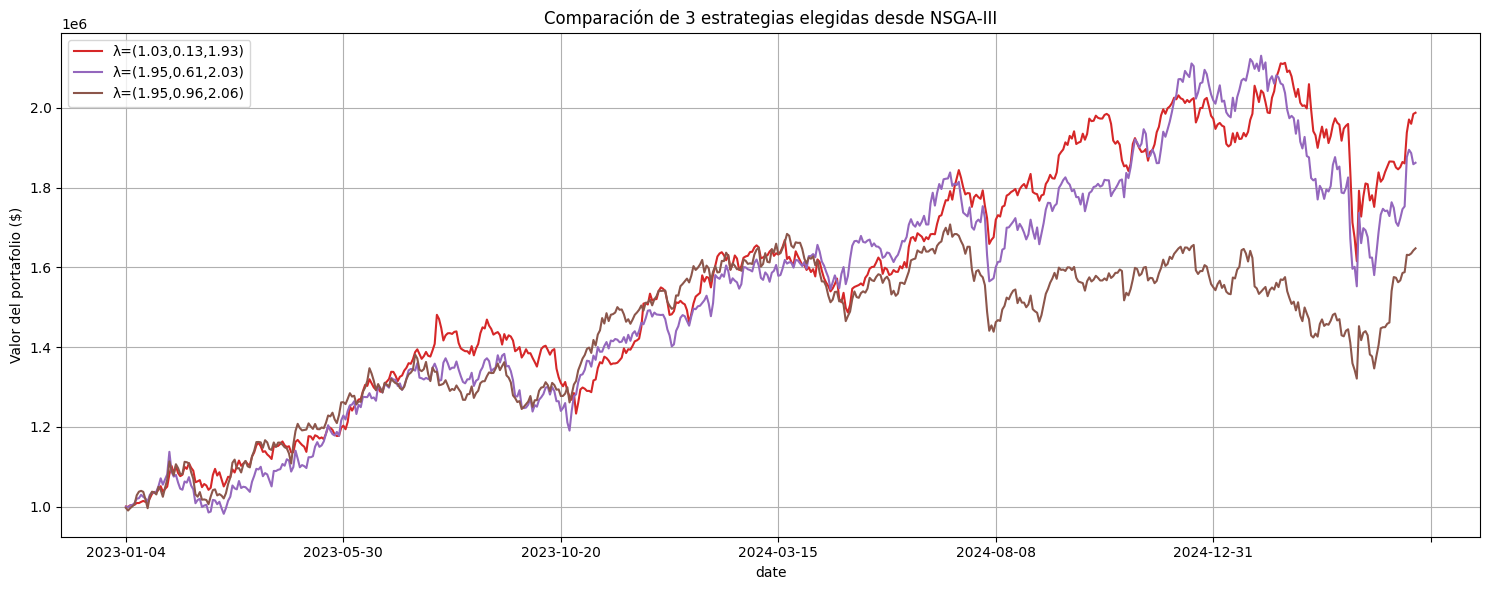

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3.common.vec_env import DummyVecEnv

# === 1. Cargar resultados de NSGA-III ===
df_resultados = pd.read_csv("resultados_nsga3.csv")
top_lambdas = df_resultados.sort_values(by="r1", ascending=False).head(3)

# === 2. Guardar resultados por portafolio ===
resultados_dict = {}

# === 3. Entrenar y evaluar con cada conjunto de lambdas ===
for idx, row in top_lambdas.iterrows():
    lambda1, lambda2, lambda3 = row["lambda1"], row["lambda2"], row["lambda3"]
    
    env_kwargs = {
        "hmax": 1_000,
        "initial_amount": 1_000_000,
        "buy_cost_pct": [0.001] * stock_dimension,
        "sell_cost_pct": [0.001] * stock_dimension,
        "state_space": state_space,
        "stock_dim": stock_dimension,
        "tech_indicator_list": INDICATORS,
        "action_space": stock_dimension,
        "reward_scaling": 1e-4,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "lambda3": lambda3,
        "esg_dict": ESG_dict
    }

    env_train = StockTradingMultiEnv(df=train, **env_kwargs)
    agent = DRLAgent(env=env_train)
    model = agent.get_model("ppo", verbose=0)
    trained_model = agent.train_model(model, tb_log_name="compare_nsga3", total_timesteps=50_000)

    env = DummyVecEnv([lambda: StockTradingMultiEnv(df=trade, **env_kwargs)])
    obs = env.reset()
    account_values = []
    for _ in range(len(trade.date.unique()) - 1):
        action, _ = trained_model.predict(obs, deterministic=True)
        obs, reward, done, info = env.step(action)
        raw_env = env.envs[0]
        account_values.append(raw_env.portfolio_value)
        if done:
            break

    nombre = f"λ=({lambda1:.2f},{lambda2:.2f},{lambda3:.2f})"
    resultados_dict[nombre] = account_values

# === 4. Convertir a DataFrame para graficar ===
df_comparacion = pd.DataFrame(resultados_dict)
df_comparacion["date"] = trade.date.unique()[1:]
df_comparacion.set_index("date", inplace=True)

# === 5. Graficar comparación con colores personalizados ===
plt.figure(figsize=(15, 6))
custom_colors = ['#d62728', '#9467bd', '#8c564b']  # rojo, púrpura, marrón
df_comparacion.plot(color=custom_colors, title="Comparación de 3 estrategias elegidas desde NSGA-III")
plt.ylabel("Valor del portafolio ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("Comparacion_3_Politicas_NSAG3.png")
plt.show()

# Frente de Pareto 

Se visualiza el frente de Pareto después de haber ejecutado NSGA3.

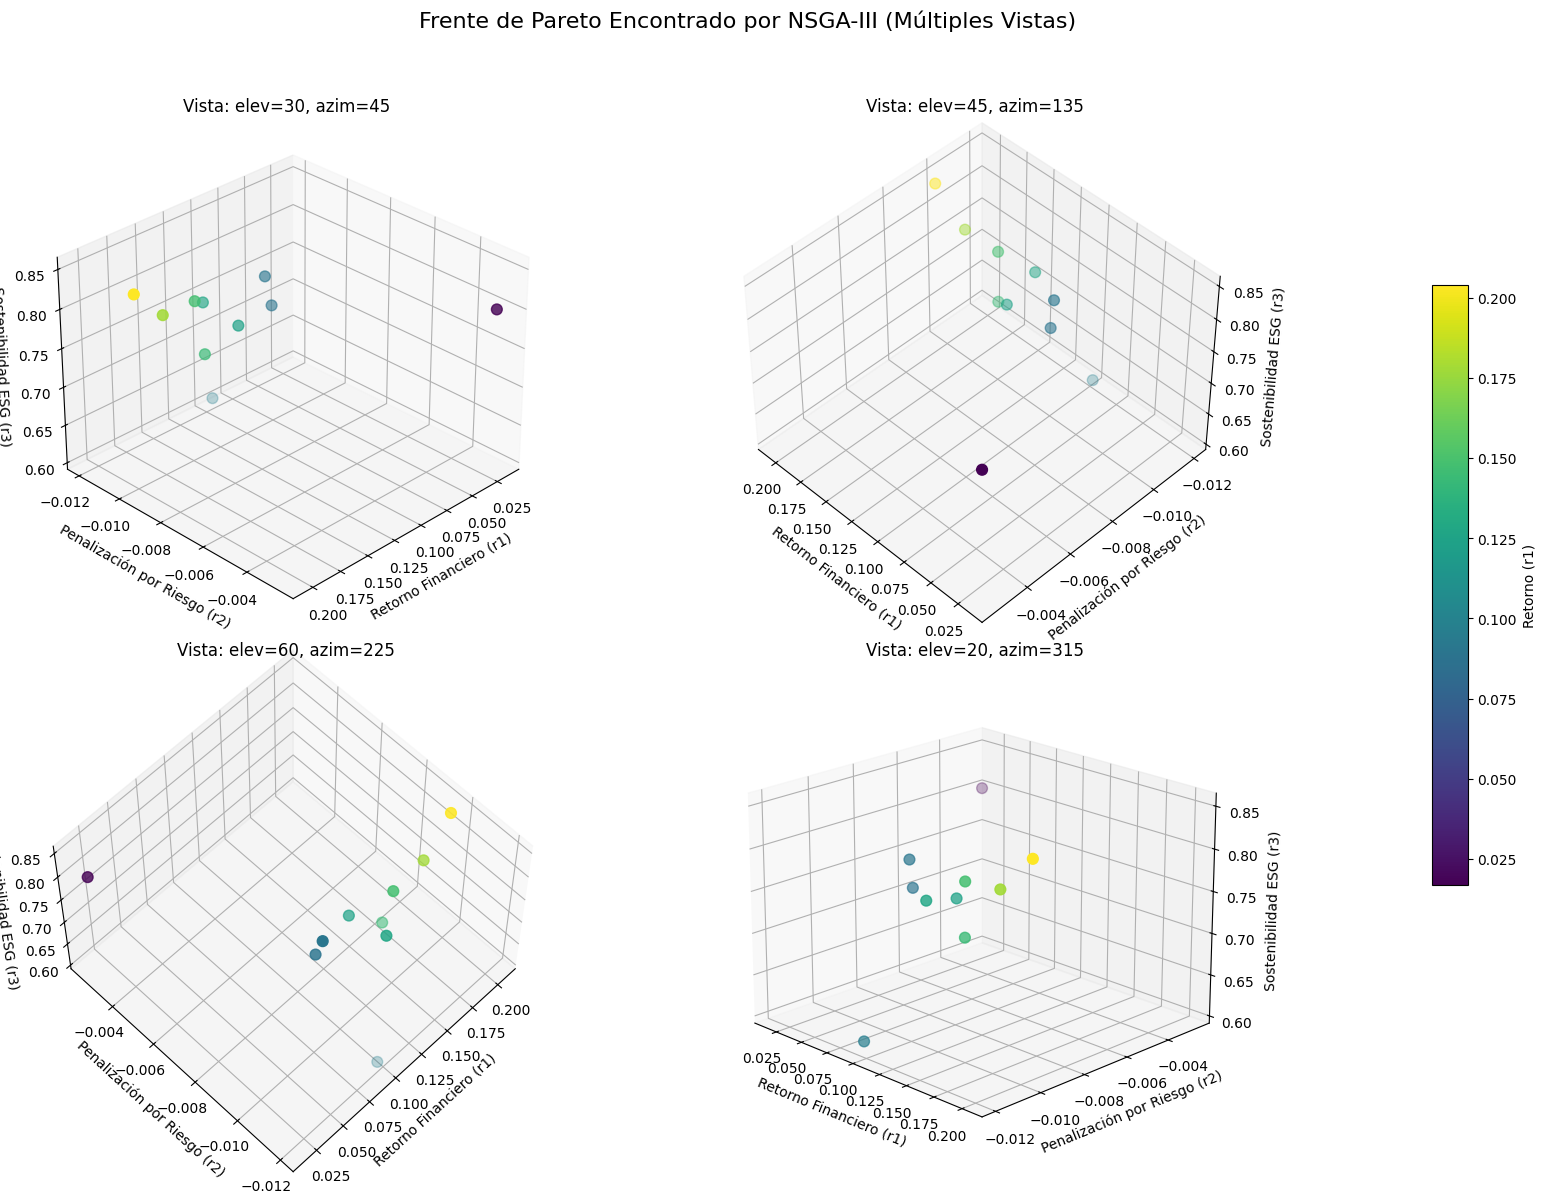

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Cargar los resultados de NSGA-III
df = pd.read_csv("resultados_nsga3.csv")
r1 = df["r1"]
r2 = df["r2"]
r3 = df["r3"]

# Ángulos desde los que se observará el gráfico
view_angles = [(30, 45), (45, 135), (60, 225), (20, 315)]

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))
for i, (elev, azim) in enumerate(view_angles):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    sc = ax.scatter(r1, r2, r3, c=r1, cmap='viridis', s=60)
    ax.set_title(f"Vista: elev={elev}, azim={azim}")
    ax.set_xlabel("Retorno Financiero (r1)")
    ax.set_ylabel("Penalización por Riesgo (r2)")
    ax.set_zlabel("Sostenibilidad ESG (r3)")
    ax.view_init(elev=elev, azim=azim)

# Agregar colorbar general
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
fig.colorbar(sc, cax=cbar_ax, label="Retorno (r1)")

plt.suptitle("Frente de Pareto Encontrado por NSGA-III (Múltiples Vistas)", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.87, 0.95])
plt.savefig("FrentePareto_NSAG3_Vistas.png")
plt.show()